# Machine learning approach 

During this notebook, we are testing different ML algorithms to tackle hypoglycemia prediction problem  

Create our own class to compare different models against several horizons and metrics

In [1]:
import os 
import pandas as pd 
import numpy as np 
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from sklearn.model_selection import TimeSeriesSplit
from sklearn.base import clone
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import sys
sys.path.append("..")
from scripts.window_regressor import Window_Regressor_Sequence_to_scalar

In [3]:
class Models_Horizon():
    def __init__(self, cut_point:int, test_size:float , window_size:int, horizon:int, folds:int, models:list, model_names:list, metrics:list):
        self.cut_point = cut_point
        self.test_size = test_size
        self.window_size = window_size
        self.horizon = horizon
        self.folds = folds
        self.models = models
        self.model_names = model_names
        self.metrics = metrics


        self.patients = self.load_patients()
        self.results = None
    
    def load_patients(self):
        data_dir = '../Data/Preprocessed'
        base_paths = os.listdir(data_dir)
        full_paths = [os.path.join(data_dir, p) for p in base_paths]
        patients = {}
        spliter = TimeSeriesSplit(n_splits=self.folds, test_size=288) ## We test using one day
        for i, fp in enumerate(full_paths):
            key = base_paths[i].split('.')[0]
            patients[key] = []
            data = pd.read_csv(fp, sep=';')[:self.cut_point]['glucose']
            for k_fold in spliter.split(data):
                k_train = data[k_fold[0]]
                k_test = data[k_fold[1]]
                proper_ml_train_k_fold = Window_Regressor_Sequence_to_scalar(time_series_data=k_train, window_size=self.window_size, horizon=self.horizon)
                proper_ml_test_k_fold = Window_Regressor_Sequence_to_scalar(time_series_data=k_test, window_size=self.window_size, horizon=self.horizon)
                patients[key].append((proper_ml_train_k_fold.generated_data_set, proper_ml_test_k_fold.generated_data_set))
        return patients
    
    def test_models(self):
        keys = list(self.patients.keys())
        results = []
        for key in keys:
            data_folds = self.patients[key] ## A list of tuples 
            columns = data_folds[0][0].columns ## Just to extract columns
            tensor_results_metrics = np.zeros(shape=(len(self.model_names), len(self.metrics), self.folds)) ## 3 cause, we're measuring MSE,MAE and MAPE

            for k, fold in enumerate(data_folds):
                train_k, test_k = fold[0], fold[1]
                X_train_k, y_train_k = train_k[columns[:-1]], train_k[columns[-1]]
                X_test_k, y_test_k = test_k[columns[:-1]], test_k[columns[-1]]
                for m, model in enumerate(self.models):
                    model = clone(model)
                    model.fit(X_train_k, y_train_k)
                    y_pred_k = model.predict(X_test_k)
                    for z, metric in enumerate(self.metrics):
                        result_metric = metric(y_true=y_test_k, y_pred=y_pred_k)
                        tensor_results_metrics[m][z][k] = result_metric
                        
            mse_all_models = tensor_results_metrics[:, 0, :]
            mae_all_models = tensor_results_metrics[:, 1, :]
            mape_all_models = tensor_results_metrics[:, 2, :]

            results.append(list(np.mean(mse_all_models, axis=1)) + list(np.mean(mae_all_models, axis=1)) + list(np.mean(mape_all_models, axis=1)))

        ### Prepare and return a df 
        metrics = ['mse', 'mae', 'mape']
        col_index = pd.MultiIndex.from_product([metrics, self.model_names], names=['metric', 'model'])
        df_final = pd.DataFrame(
            results,
            index=keys,
            columns=col_index
        )
        self.results = df_final
        return df_final

    def visualize_model_comparison(self, figsize=(15, 7)):
        if self.results is None:
            raise ValueError("No results to visualize. Run 'test_models()' first.")
    

        metrics = ['mse', 'mae', 'mape']
        model_names = self.model_names

        _, axes = plt.subplots(1, 3, figsize=figsize)
        colors = ['steelblue', 'seagreen', 'tomato']

        for ax, metric, color in zip(axes, metrics, colors):

            data_plot = self.results[metric]  

            data_long = data_plot.reset_index().melt(
                id_vars='index',
                var_name='Model',
                value_name=metric.upper()
            )
            data_long['Model'] = pd.Categorical(data_long['Model'], categories=model_names)

    
            sns.boxplot(
                data=data_long,
                x='Model',
                y=metric.upper(),
                ax=ax,
                color=color,
                width=0.6
            )

            ax.set_title(f'{metric.upper()}: Window_size:{self.window_size}, Horizon:{self.horizon}')
            ax.set_xlabel('Modelo')
            ax.set_ylabel(metric.upper())
            ax.tick_params(axis='x', rotation=45)
            ax.grid(axis='y', linestyle='--', alpha=0.7)

        plt.tight_layout()
        plt.show()
        
        ## Visualize a summary for each metric
        for m in metrics:
            print(f'{m.upper()}')
            print(self.results[m].describe())
        

## Test it using random forest regressor and gradient boost regressor 

In [24]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor


In [ ]:
cut_point = 2290
test_size = 0.2
window_size = 6
horizon = 3
folds = 5
models = [
    RandomForestRegressor(
        n_estimators=100,
        max_depth=3,          
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42
    ),
    GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,          
        min_samples_split=10,
        min_samples_leaf=5,
        subsample=0.8,
        random_state=42
    ),
    XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,          # ← más bajo
        min_child_weight=10,  # ← clave para evitar hojas pequeñas
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        objective='reg:squarederror'
    ),
    LinearRegression(),
    KNeighborsRegressor(
    n_neighbors=5,
    weights='distance'  # más peso a vecinos cercanos
    ),
    CatBoostRegressor(
    iterations=100,
    learning_rate=0.1,
    depth=3,
    random_seed=42,
    verbose=False
)

]
model_names = ['random_forest', 'gradient_boost', 'xgboost', 'linear_regression', 'KNN_regressor', 'CatBoost']
metrics = [mean_squared_error, mean_absolute_error, mean_absolute_percentage_error]

In [27]:
horizon_3 = Models_Horizon(
    cut_point=cut_point, 
    test_size=test_size, 
    window_size=window_size, 
    horizon=horizon, 
    folds=folds,
    models=models, 
    model_names=model_names, 
    metrics=metrics
)

In [28]:
results = horizon_3.test_models()

In [29]:
results.shape

(25, 18)

In [30]:
results

metric              mse                                               \
model     random_forest gradient_boost     xgboost linear_regression   
HUPA0004P    294.612656     121.081202  148.604920         55.523421   
HUPA0006P    327.157289     176.042282  209.895852         50.017578   
HUPA0007P    533.347018     386.121210  423.743115        411.876662   
HUPA0009P    121.626213      77.296513   70.410954         15.030784   
HUPA0005P    169.278874     121.489767  139.018882         98.765939   
HUPA0011P    446.516260     281.210951  338.863305        135.823583   
HUPA0003P    221.798014     161.901373  174.796027        132.065859   
HUPA0001P    489.223574     390.728822  395.549119        266.458191   
HUPA0010P    302.083184     195.853767  242.003472         95.921505   
HUPA0002P    148.743149      87.443406  102.275477         38.986920   
HUPA0014P    679.206677     482.190544  534.269735         52.148677   
HUPA0015P    231.423131     121.210925  154.098992         46.236279   
HUPA0016P    207.334946     108.883349  128.166152         59.820836   
HUPA0017P    170.374476     105.084052  126.494419         67.396896   
HUPA0018P    239.276429     109.624955  134.588560         56.615224   
HUPA0021P    242.952204     156.850895  187.186463         73.512327   
HUPA0020P    224.860621     104.760216  124.849210         48.642507   
HUPA0024P    192.473934      88.628896  104.826625         50.823299   
HUPA0019P    370.757590     178.293817  215.526146         92.877304   
HUPA0023P    223.185749     148.137199  165.564195         52.553932   
HUPA0022P    139.950587     132.556098  135.845902        123.785950   
HUPA0025P    136.604833     105.038625  113.759561         45.475262   
HUPA0028P    199.967215     141.200754  166.397838         73.783178   
HUPA0026P    213.001678     108.870208  128.705747         65.584740   
HUPA0027P    113.640805      83.937414   97.754440         55.570567   

metric                                        mae                            \
model     KNN_regressor    CatBoost random_forest gradient_boost    xgboost   
HUPA0004P    171.779163  173.422001     13.185878       8.236273   9.158171   
HUPA0006P    234.586156  256.054972     13.183147       9.384860  10.427769   
HUPA0007P    446.108246  432.402013     16.582783      13.350383  14.201506   
HUPA0009P     85.108230  104.127329      7.171210       4.392699   4.495921   
HUPA0005P    176.034745  149.022688      9.834064       8.116801   8.758089   
HUPA0011P    385.310171  316.178235     14.024489      11.291502  12.399406   
HUPA0003P    183.886023  181.663172     11.159665       8.740454   9.363828   
HUPA0001P    553.960737  407.832150     15.655150      12.940827  13.490357   
HUPA0010P    269.278441  262.386766     10.720418       6.898563   7.707027   
HUPA0002P    127.177035  116.473362      8.899506       6.750204   7.355072   
HUPA0014P    568.294245  544.519717     13.144383       9.596125  10.356617   
HUPA0015P    159.939032  160.872448     10.965510       7.983907   9.035086   
HUPA0016P    161.940560  167.628681     10.555770       7.624107   8.368465   
HUPA0017P    138.818791  153.078030      9.846558       7.546684   8.400079   
HUPA0018P    163.467710  166.087632     11.724971       7.387195   8.275965   
HUPA0021P    207.463761  180.866685     11.121284       8.697528   9.666219   
HUPA0020P    140.737205  168.668232     11.817265       7.774312   8.566172   
HUPA0024P    134.202095  141.603079     10.456800       6.999710   7.638656   
HUPA0019P    271.246208  223.760973     13.949190       9.340043  10.245401   
HUPA0023P    181.050708  171.777682     10.202276       7.629654   8.345630   
HUPA0022P    143.632103  136.014615      8.026791       7.848117   8.112675   
HUPA0025P    118.642370  113.521503      8.159067       6.600666   7.066120   
HUPA0028P    165.945844  165.976234      9.571069       7.641994   8.365154   
HUPA0026P    154.138709  150.532685     11.238794       7.328719   8.117806   
H

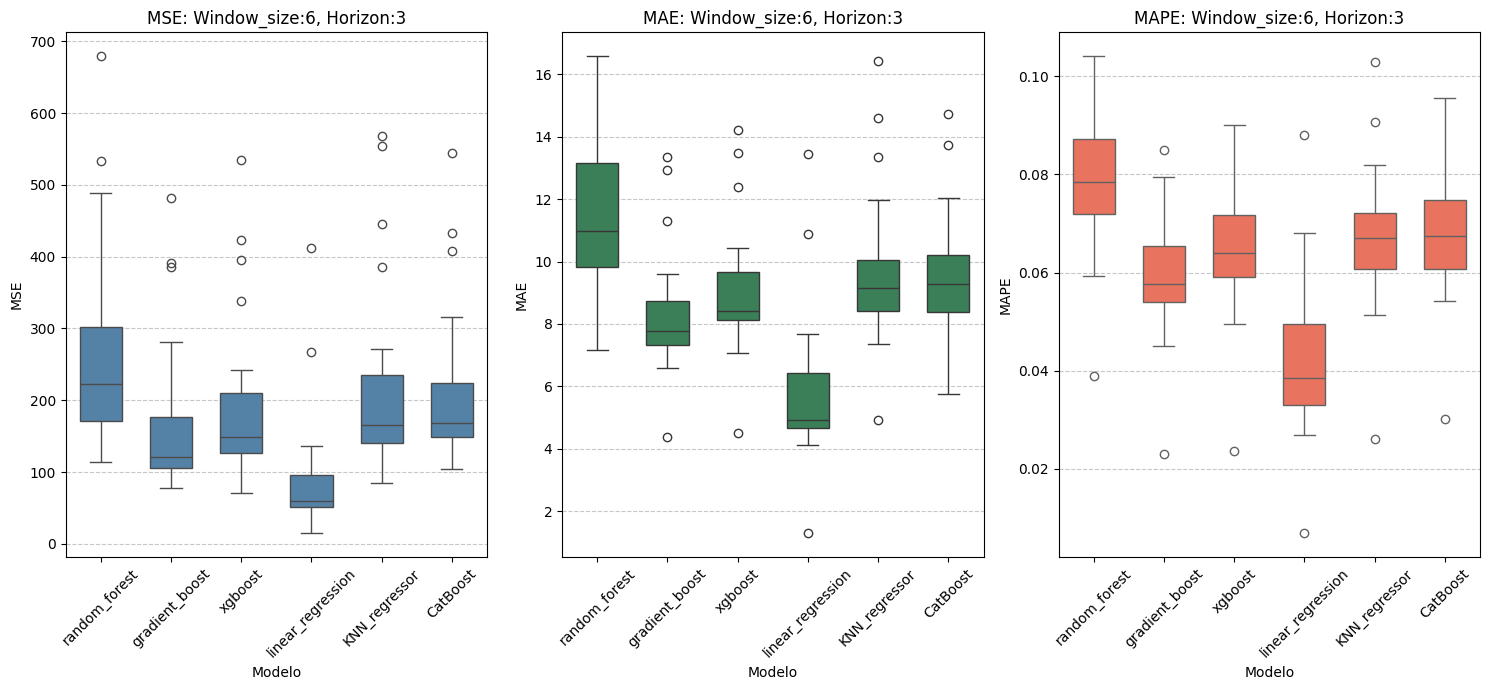

MSE
model  random_forest  gradient_boost     xgboost  linear_regression  \
count      25.000000       25.000000   25.000000          25.000000   
mean      265.575884      166.977490  190.527804          90.611897   
std       140.584159      105.894088  114.335466          83.092349   
min       113.640805       77.296513   70.410954          15.030784   
25%       170.374476      105.084052  126.494419          50.823299   
50%       223.185749      121.489767  148.604920          59.820836   
75%       302.083184      176.042282  209.895852          95.921505   
max       679.206677      482.190544  534.269735         411.876662   

model  KNN_regressor    CatBoost  
count      25.000000   25.000000  
mean      218.843317  205.967229  
std       131.140717  110.237795  
min        85.108230  104.127329  
25%       140.737205  149.022688  
50%       165.945844  167.628681  
75%       234.586156  223.760973  
max       568.294245  544.519717  
MAE
model  random_forest  gradient_boost 

In [31]:
horizon_3.visualize_model_comparison()